In [2]:
import os
from mistralai import Mistral
import os
import json
import random
import time

In [3]:
api_key = "ujI60UR6Fe5jel48SAtfnMiN5Skxfwhq"
#kostenlloses model
model =  "open-mistral-nemo"
client = Mistral(api_key=api_key)

In [4]:
# File paths
input_path = r"C:\Users\cdoering\Downloads\filtered_output.json"
output_dir = "ontology_output"
os.makedirs(output_dir, exist_ok=True)
output_file_path = os.path.join(output_dir, "ontology_try_chiara.json")

In [ ]:
import os
import json
import random
import time
import re

# === File paths ===
input_path = r"C:\Users\cdoering\Downloads\filtered_output.json"
cq_path = r"C:\Users\cdoering\OneDrive - IW\Dokumente\Capstone\CapstoneDATEV25\competency_questions_output\competency_questions_all_documents.txt"
output_file_path = "ontology_output/ontology_with_cq.json"
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

# === Load documents ===
with open(input_path, "r", encoding="utf-8") as f:
    documents = json.load(f)

# === Load competency questions ===
cq_by_doc_id = {}
with open(cq_path, "r", encoding="utf-8") as f:
    content = f.read()

cq_blocks = re.split(r'Dokument:\s*', content)
for block in cq_blocks[1:]:
    lines = block.strip().splitlines()
    doc_id = lines[0].strip()
    frage = next((l for l in lines if l.lower().startswith("frage:")), None)
    quelle = next((l for l in lines if "quelle" in l.lower()), None)
    if frage and quelle:
        cq_by_doc_id[doc_id] = {
            "question": frage.replace("Frage:", "").strip(),
            "source": quelle.replace("Quelle:", "").strip()
        }

# === Use same sampling logic as before ===
random.seed(100)
sampled_documents = dict(random.sample(list(documents.items()), 21))

# === Ontology system prompt === (also wie Ontologies generel funktionieren)
ontology_system_prompt = """
You are an expert legal ontology engineer.

Your task is to extract ontology components from the given legal ruling text (German court decisions). 
Identify and return three structured components:

1. **Classes**: Legal entities or concepts (e.g., Urteil, Entscheidungsgründe, Anspruch, Person, Tatbestand, Eiwendung, Rubrum, Tenor)
2. **Properties**: Verbs or phrases representing relationships or attributes (e.g., beinhaltet, basiert auf, verhindert, erörtern)
3. **Relationships**: Triples (Subject)-(Predicate)-(Object), connecting two classes using a property

Requirements:
- Only extract concepts if they have relationships.
- Use clear legal language in German.
- Output must follow this structure (example):

{
  "classes": ["Urteil", "Anspruch", "Tatbestand"],
  "properties": ["beinhaltet", "basiert auf"],
  "relationships": [
    ["Urteil", "beinhaltet", "Tatbestand"],
    ["Anspruch", "basiert auf", "Tatbestand"]
  ]
}

## Few-Shot Examples 
"<Example 1>"
"Sentence: 'Ein Arbeitnehmer hat eine Sozialversicherungsnummer'"
"Classes: [Arbeitnehmner, Sozialversicherungsnummer]"
"Properties: [hatIdentifikation]"
"Relationship: [(Arbeitnehmer)-(hatIdentifikation)-(Sozialversicherungsnummer)]"

"<Example 2>"
"Sentence: 'Arbeitnehmer haben nach Gesetz einen geregelten Mindestanspruch auf 24 Tage Urlaub im Jahr'"
"Classes: [Arbeitnehmer, Urlaub]"
"Properties: [hatMindestAnspruchAuf]"
"Relationship: [(Arbeitnehmer)-(hatMindestAnspruchAuf)-(Urlaub)]"

## Modelling Guidelines
"- **Concept Identification**:"
"- Identify nouns and noun phrases as potential **Classes**."
"- Identify verbs and verb phrases as potential **Properties**."
"- Identify prepositions that establish relationships between nouns."

"- **Classes**:"
"- Represent concepts in the domain, not the words that denote these concepts."
"- Avoid creating classes for synonyms; use a single class for concepts with the same meaning."

"- **Properties**:"
"- Represent significant relationships or attributes between classes."
"- Should be meaningful and represent a significant connection."

"- **Relationships**:"
"- Establish connections between classes using properties."
"- Ensure relationships are meaningful within the domain context."

"- **General Principles**:"
"- There is no single correct way to model a domain; the best solution depends on the application."
"- Ontology development is an iterative process; refine as needed."
"- Avoid cycles in the class hierarchy."
"- Siblings in the hierarchy should be at the same level of generality."

## Naming Conventions
"**General**:"
"- Do not add strings like 'class', 'domain', 'range', 'property', or 'slot' to names."
"- Use consistent naming throughout the ontology."

"**Classes**:"
"- Names are always capitalized."
"- Use nouns or compound nouns (e.g., Vertrag, Arbeit, Arbeitsvertrag)."
"- Use singular over plural (e.g., Arbeitsvertrag instead of Arbeitsverträge)."
"- Avoid abbreviations (e.g., Arbeitgeber instead of AG)."

"**Properties**:"
"- Names start with a lower-case letter."
"- Use verbs or verb phrases."
"- Can contain nouns in CamelCase starting with a verb (e.g., hatAnspruchAuf)."
"- Do not include spaces, commas, asterisks, or special characters."

##Finally
"Ensure that you include empty lists for classes, properties, or relationships if none are found."
"Make sure all extracted components, i.e. classes, properties, and relationships as well as all descriptions are in German and translate where necessary."
"Include a class only if at least one relationship is found for a class. Verify this requirement."
"Check carefully for each class without any relationship, based on the name and the description of the class, if it can be merged with another class or if it is actually a relationship between on class and another. This is particularly relevant for classes that are named in the form of 'has something'."
"All ontology components must be in German language!"
"Terms like 'range' or 'domain' are never allowed!"

Only return JSON. Do not explain or comment.
"""

# === Build prompt with CQ (if available) ===
def build_ontology_prompt(text, cq_entry=None):
    base_prompt = f"Extract ontology components from the following legal text:\n\n{text[:10000]}"
    if cq_entry:
        base_prompt += f"\n\nConsider the following competency question to guide your extraction:\nFrage: {cq_entry['question']}"
    return base_prompt

# === Main loop ===
ontology_results = {}

for i, (doc_id, doc_data) in enumerate(sampled_documents.items()):
    text_data = doc_data.get("text", {}).get("entscheidungsinhalt", {})
    gruende_list = text_data.get("gruende", {}).get("gruende", [])
    if not gruende_list:
        print(f"⚠️ Skipping {doc_id} (no 'gruende')")
        continue
    text = "\n".join(gruende_list).strip()
    cq_entry = cq_by_doc_id.get(doc_id)
    user_prompt = build_ontology_prompt(text, cq_entry)
    try:
        response = client.chat.complete(
            model=model,
            messages=[
                {"role": "system", "content": ontology_system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.5
        )
        content = response.choices[0].message.content.strip()
        try:
            ontology = json.loads(content)
            ontology_results[doc_id] = {
                "ontology": ontology,
                "competency_question": cq_entry
            }
            print(f"✅ Ontology extracted for {doc_id}")
        except json.JSONDecodeError:
            print(f"❌ Invalid JSON for {doc_id}, skipping.")
        time.sleep(1)
    except Exception as e:
        print(f"❌ Error for {doc_id}: {e}")

# === Save results ===
with open(output_file_path, "w", encoding="utf-8") as f_out:
    json.dump(ontology_results, f_out, indent=2, ensure_ascii=False)

print("✅ Ontology extraction with competency questions completed.")


✅ Ontology extracted for 1548765.xml
✅ Ontology extracted for 1549417.xml
✅ Ontology extracted for 1567715.xml
✅ Ontology extracted for 1658302.xml
✅ Ontology extracted for 1569756.xml
⚠️ Skipping 1681077.xml (no 'gruende')
✅ Ontology extracted for 1536966.xml
✅ Ontology extracted for 1525185.xml
✅ Ontology extracted for 0960919.xml
✅ Ontology extracted for 1541664.xml
⚠️ Skipping 1682044.xml (no 'gruende')
✅ Ontology extracted for 1570226.xml
✅ Ontology extracted for 1521301.xml
✅ Ontology extracted for 1596648.xml
✅ Ontology extracted for 1544176.xml
✅ Ontology extracted for 1590874.xml
✅ Ontology extracted for 1526301.xml
✅ Ontology extracted for 1657134.xml
✅ Ontology extracted for 1532441.xml
✅ Ontology extracted for 1568706.xml
✅ Ontology extracted for 1535555.xml
✅ Ontology extraction with competency questions completed.


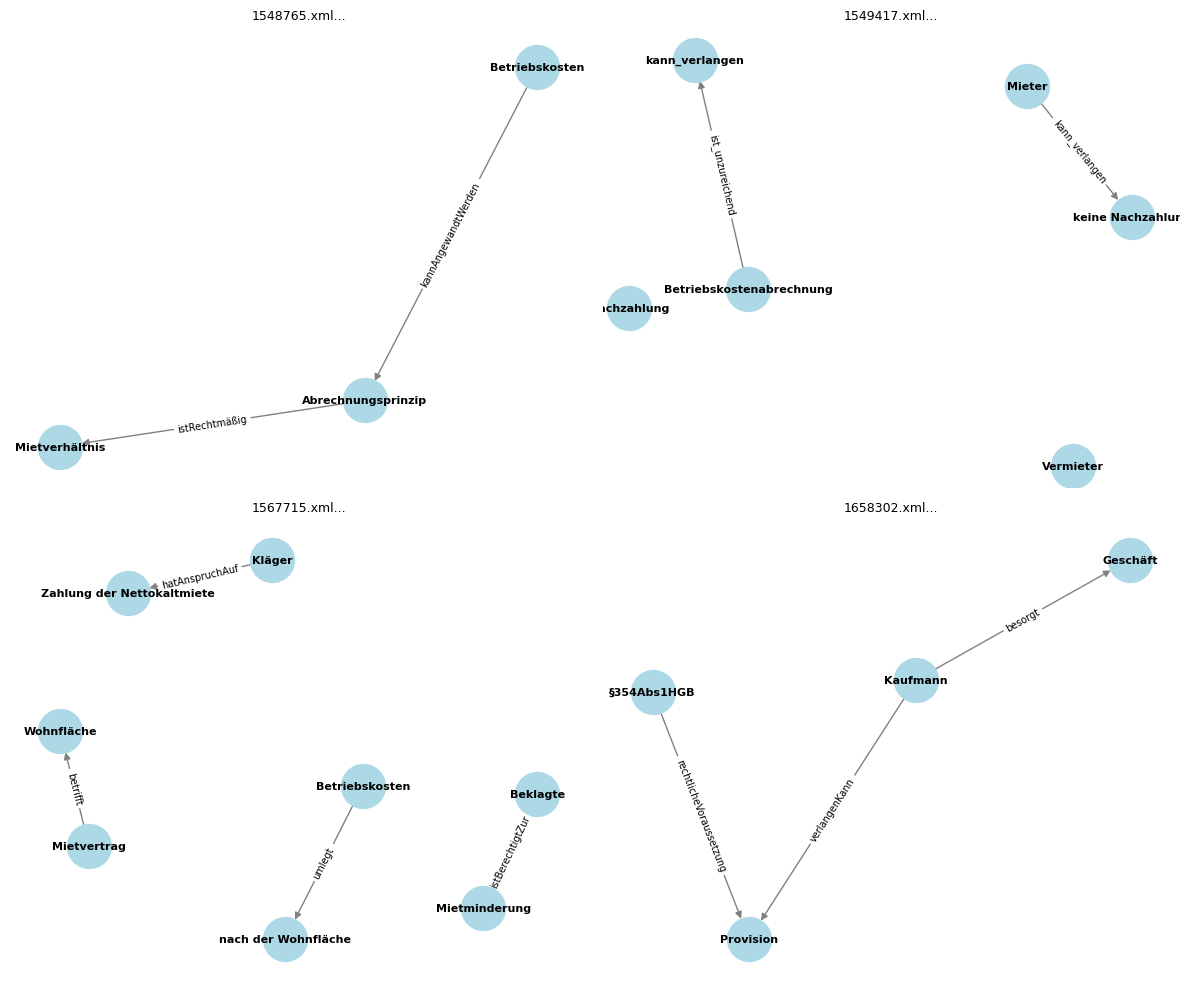

In [11]:
import json
import os
import matplotlib.pyplot as plt
import networkx as nx

# Load your ontology file
ontology_path = "ontology_output/ontology_with_cq.json"
with open(ontology_path, "r", encoding="utf-8") as f:
    ontology_data = json.load(f)

# Parameters
num_graphs = 4  # Number of ontologies to show
cols = 2        # How many graphs per row
rows = (num_graphs + cols - 1) // cols  # Rows needed

# Prepare figure
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
axes = axes.flatten()

# Draw each ontology
for i, doc_id in enumerate(list(ontology_data.keys())[:num_graphs]):
    ontology = ontology_data[doc_id]["ontology"]
    classes = ontology.get("classes", [])
    relationships = ontology.get("relationships", [])

    G = nx.DiGraph()
    G.add_nodes_from(classes)
    for subj, pred, obj in relationships:
        G.add_edge(subj, obj, label=pred)

    pos = nx.spring_layout(G, k=1.2, seed=42)
    ax = axes[i]
    ax.set_title(f"{doc_id[:30]}...", fontsize=9)

    nx.draw(G, pos, with_labels=True, ax=ax,
            node_color="lightblue", node_size=1000,
            font_size=8, font_weight="bold", edge_color="gray")

    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

# Hide unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
